In [71]:
# import packages
import math
import os
import csv
from pathlib import Path
import json
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
from torchinfo import summary
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

from tqdm.auto import tqdm

from utils.data_load import DataModule # used to load dataset and create dataloaders

In [72]:
# set device to gpu when available
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [73]:
# create directories to save model checkpoints and generated samples
root_dir = Path("kaggle/working/diffusion_model_")
checkpoint_dir = root_dir / "checkpoints"
plot_dir = root_dir / "plots"
history_dir = root_dir / "history"

# checkpoint_dir.mkdir(parents=True, exist_ok=True)
# plot_dir.mkdir(parents=True, exist_ok=True)
# history_dir.mkdir(parents=True, exist_ok=True)

### **Load Data**

In [74]:
# load in dataset and create dataloaders using data_load.datamodule class
# using datamodule class to load data
dm = DataModule(
    repo_id="han2o/grant-ortsaem-processedV2", # hugging face repo id for dataset
    gap="0.5",  #  gap version [0.5, 2.0, 3.0, 5.0]
    input_key="masked_spectrogram",
    target_key="spectrogram",
    mask_key="mask",
    batch_size=8, # batch size for dataloaders
    num_workers=0,
    streaming=True,
    # maximum number of training/ validation/ test samples. Set to None to use the entire dataset.
    max_train_samples=128, 
    max_val_samples=32,
    max_test_samples=32, 
)

train_loader, val_loader, test_loader = dm.setup()

In [5]:
# inspect one batch of data
batch = next(iter(train_loader))

print("keys:", batch.keys())
print("x shape:", batch["x"].shape)
print("y shape:", batch["y"].shape)
print("mask shape:", batch["mask"].shape)

if "gap_seconds" in batch:
    print("example gap:", batch["gap_seconds"][0])

keys: dict_keys(['x', 'y', 'mask', 'example_id', 'split', 'recording_idx', 'clip_idx', 'audio_filename', 'sample_rate', 'clip_duration_seconds', 'n_mels', 'time_frames', 'hop_length', 'gap_seconds', 'gap_frames', 'mask_start_frame', 'mask_end_frame'])
x shape: torch.Size([8, 1, 128, 1876])
y shape: torch.Size([8, 1, 128, 1876])
mask shape: torch.Size([8, 1, 128, 1876])
example gap: tensor(0.5000, dtype=torch.float64)


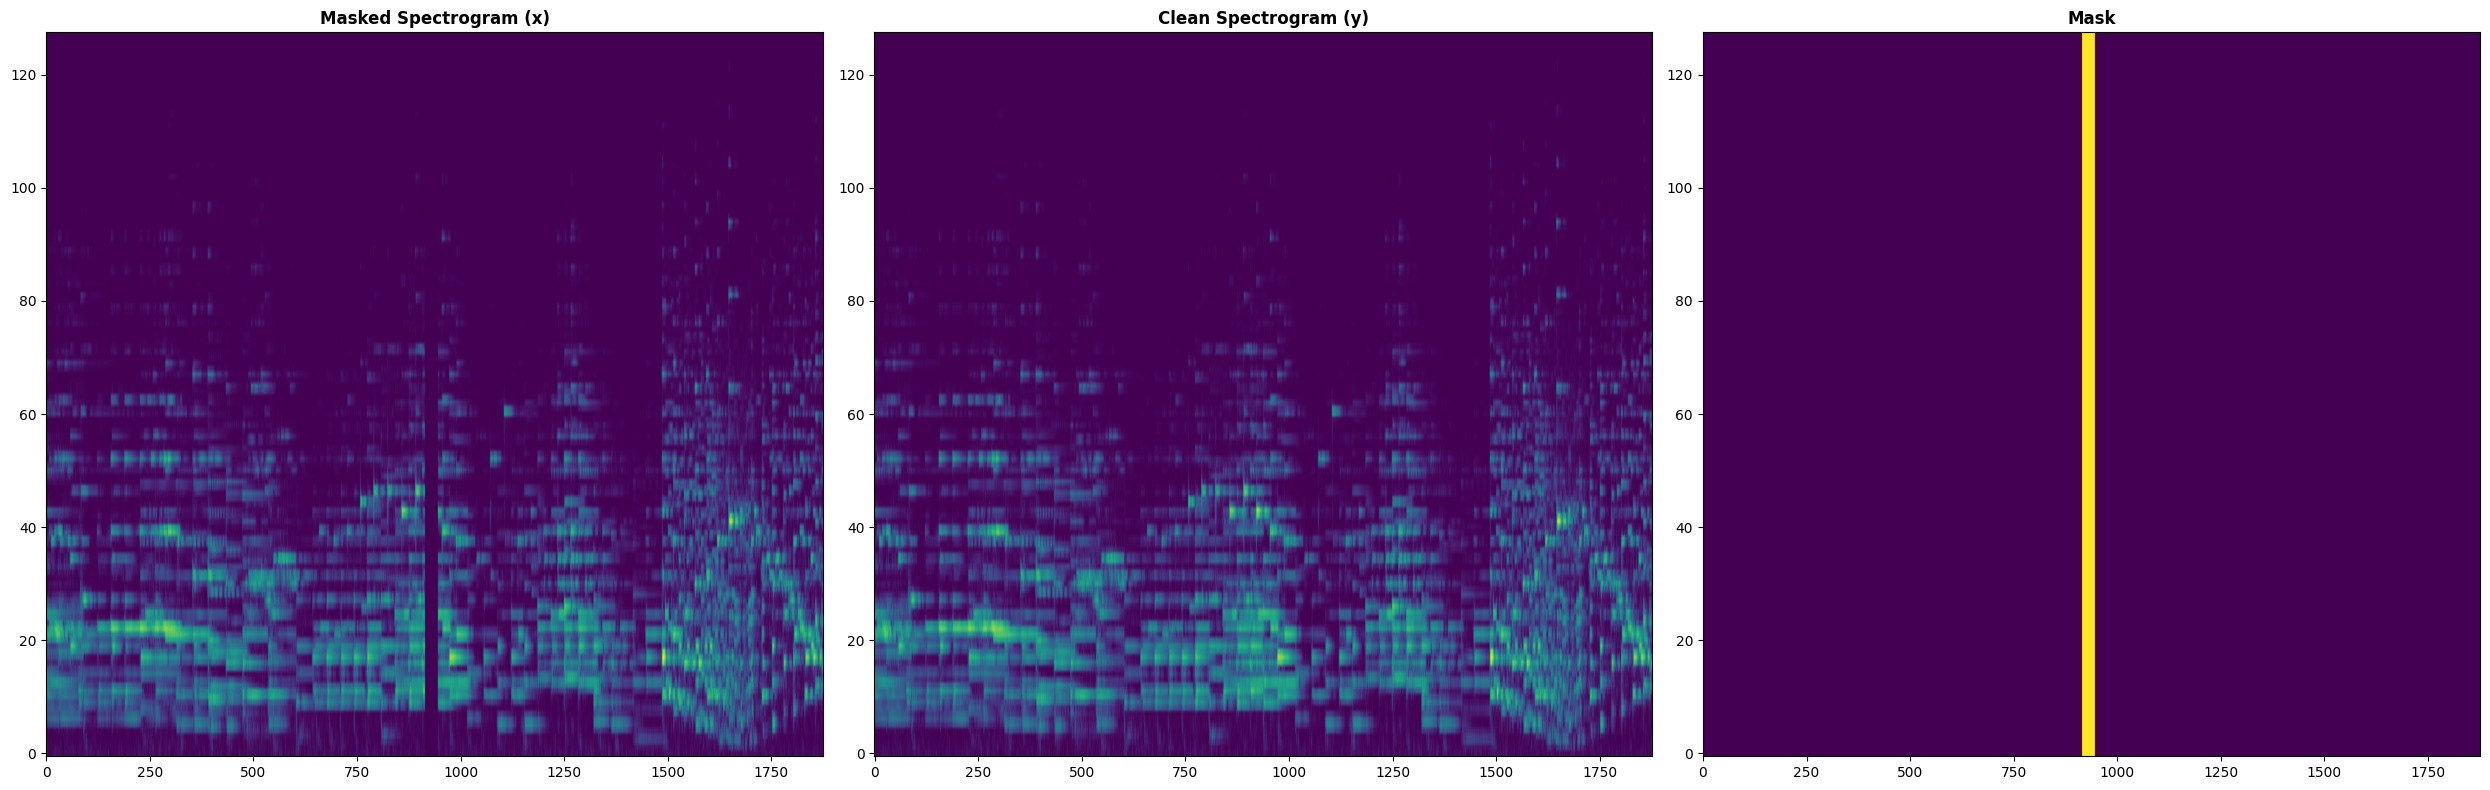

In [12]:
# visualise a sample spectrogram, mask, and target
x = batch["x"][0, 0].cpu().numpy()
y = batch["y"][0, 0].cpu().numpy()
m = batch["mask"][0, 0].cpu().numpy()

plt.figure(figsize=(25, 8))

plt.subplot(1, 3, 1)
plt.imshow(x, aspect="auto", origin="lower")
plt.title("Masked Spectrogram (x)", weight="bold")

plt.subplot(1, 3, 2)
plt.imshow(y, aspect="auto", origin="lower")
plt.title("Clean Spectrogram (y)", weight="bold")

plt.subplot(1, 3, 3)
plt.imshow(m, aspect="auto", origin="lower")
plt.title("Mask", weight="bold")

plt.tight_layout()
plt.show()

---

### **Building VAE**

VAE is introduced to learn a compressed latent representation of the spectorgram. The input spectrogram may be very large in spatial size, so the U-Net becomes expensive in memory to compute. 

We first encode the spectrogram into smaller latent tensor, ensuring that the latent space preserves the important structure. We then proceed to decode the latent space back into the original spectrogram. So the VAE is learning a mapping:
$$
x \rightarrow z \rightarrow \hat{x}
$$

---
For each of these input $x$, the encoder predicts the parameters of a Gaussian latent distribution 
$$
q_\phi(z \mid x) = \mathcal{N}\bigl(z;\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))\bigr)
$$

Hence the encoder outputs, $\mu = \mu_\phi(x)$ and $\log \sigma^2 = \text{logvar}_{\phi(x)}$.

Then, the latent sample is obtained using the reparameterisation trick:
$$
z = \mu + \sigma * \epsilon
$$

where $\sigma = \exp\left(\frac{1}{2} \text{logvar}\right), \qquad \epsilon \sim \mathcal{N}(0, I)$

The decoder then reconstructs:
$$
\hat{x} = p_\theta(x \mid z)
$$
---

The VAE architecture has 3 main blocks:
- Encoder
- Latent Sampling
- Decoder

---

#### **VAE Helper Functions and Class Utilities**

In [14]:
# padding helper function
# VAE and U-NEt will downsample by powers of 2, with 4 downsampling stage, both height and width shoudl be dividable by 16 to avoid size mismatch issues
# padding is added to the right and bottom of the spectrogram, and removed after model output

# pad the last two dimensions (H, W) so they are divisible by the specified multiple
def padding(x, multiple=16):

    # padding the last 2 dim
    b, c, h, w = x.shape

    # amount of padding needed for height
    pad_h = (multiple -( h % multiple)) % multiple
    # amount of padding needed for width
    pad_w = (multiple -( w % multiple)) % multiple

    # pad format for 4d tensor
    x_pad = F.pad(x, (0, pad_w, 0, pad_h), mode="constant", value=0.0)

    pad_info = {
        "orig_h": h,
        "orig_w": w,
        "pad_h": pad_h,
        "pad_w": pad_w,
    }
    return x_pad, pad_info

# remove padding that was added
def unpadding(x, pad_info):
    return x[..., :pad_info["orig_h"], :pad_info["orig_w"]]


In [15]:
# sinusoidal timestamp embedding  
# a key element of diffusion model, is to condition on the current timestep in each diffusion step
# this function generates a sinusoidal embedding for a given timestep, which can be added to the model's input to provide temporal information

# convert integer timestep into sinusoidal embedding vector
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    # create sinusoidal embeddings like in diffusion models
    def forward(self, t):
        half_dim = self.dim // 2

        # create frequency scale
        freq_factor = math.log(10000) / max(half_dim - 1, 1)
        freqs = torch.exp(
            torch.arange(half_dim, device=t.device, dtype=torch.float32) * (-freq_factor)
        )

        # shape: [B, half_dim]
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        # concatenate sin and cos
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        # if dim is odd, pad one extra feature
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb

In [ ]:
# VAE architecture blocks for spectrogram denoising

# Convblock -> GroupNorm + SiLu activation
class ConvGNSiLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, groups=8):
        super().__init__()

        # convolutional layer
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )

        # GroupNorm is more stable than BatchNorm for diffusion
        self.norm = nn.GroupNorm(num_groups=min(groups, out_channels), num_channels=out_channels)

        # SiLU is a smooth nonlinearity commonly used in modern diffusion models
        self.act = nn.SiLU()
    
    # forward pass
    def forward(self, x):
        x = self.conv(x)
        x = self.norm(x)
        x = self.act(x)
        return x

# 2D residual blocks with toggle time embedding conditioning
# residual block is used to that the model learns to keep onlyu useful information and change what is needed simialr to resnet
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=None, groups=8):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.time_emb_dim = time_emb_dim

        # first normalization + convolution path
        self.norm1 = nn.GroupNorm(num_groups=min(groups, in_channels), num_channels=in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        # if we are using timestep conditioning, project time embedding to channel size
        if time_emb_dim is not None:
            self.time_proj = nn.Linear(time_emb_dim, out_channels)
        else:
            self.time_proj = None

        # second normalization + convolution path
        self.norm2 = nn.GroupNorm(num_groups=min(groups, out_channels), num_channels=out_channels)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # if input/output channels differ, use a 1x1 conv for residual path
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    # forward pass
    def forward(self, x, t_emb=None):
        """
        x: [B, C, H, W]
        t_emb: [B, time_emb_dim]
        """
        residual = self.skip(x)

        # first conv path
        h = self.norm1(x)
        h = self.act1(h)
        h = self.conv1(h)

        # inject time embedding after the first conv
        if self.time_proj is not None and t_emb is not None:
            # project [B, time_emb_dim] -> [B, out_channels]
            t_out = self.time_proj(t_emb)

            # reshape to [B, out_channels, 1, 1] so it can broadcast spatially
            h = h + t_out[:, :, None, None]

        # second conv path
        h = self.norm2(h)
        h = self.act2(h)
        h = self.conv2(h)

        # residual addition
        return h + residual

# downsampling blocks
# reduce spatial resolution by factor of 2 using stride-2 convolution
# if input is [B, C, H, W], output will be [B, C, H/2, W/2]
class DownSample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

# updating blocks
# increase spatial resoltuion by factor of 2
# use nearest neighbor upsampling followed by a convolution to reduce checkerboard artifacts
class UpSample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        # double height and width
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = self.conv(x)
        return x
    
# attention block over spatial positions, natural u-net architecture adds attention at the bottleneck
class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        assert channels % num_heads == 0, "channels must be divisible by num_heads"

        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.norm = nn.GroupNorm(num_groups=min(8, channels), num_channels=channels)

        # q, k, v projections
        self.to_q = nn.Conv2d(channels, channels, kernel_size=1)
        self.to_k = nn.Conv2d(channels, channels, kernel_size=1)
        self.to_v = nn.Conv2d(channels, channels, kernel_size=1)

        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)

    # forward pass
    def forward(self, x):
        b, c, h, w = x.shape
        residual = x

        x = self.norm(x)

        q = self.to_q(x)
        k = self.to_k(x)
        v = self.to_v(x)

        # reshape to [B, heads, head_dim, H*W]
        q = q.view(b, self.num_heads, self.head_dim, h * w)
        k = k.view(b, self.num_heads, self.head_dim, h * w)
        v = v.view(b, self.num_heads, self.head_dim, h * w)

        # transpose q to [B, heads, HW, head_dim]
        q = q.permute(0, 1, 3, 2)

        # attention scores: [B, heads, HW, HW]
        attn_scores = torch.matmul(q, k) / math.sqrt(self.head_dim)
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # apply attention to values
        # v: [B, heads, head_dim, HW] -> transpose to [B, heads, HW, head_dim]
        v = v.permute(0, 1, 3, 2)

        out = torch.matmul(attn_weights, v)  # [B, heads, HW, head_dim]

        # back to [B, C, H, W]
        out = out.permute(0, 1, 3, 2).contiguous().view(b, c, h, w)
        out = self.proj_out(out)

        return out + residual


#### **Convolutional Spatial Encoder**

Encoder takes a 1 channel spectrogram and converts it into a low-resolution latent representation

The encoder first projects from 1 channel (B, 1, H, W) to larger channel dimensions (B, 64, H, W) for richer feature space learning.

It then applies 4 resolution reduction stages, where each stage contains a residual block and then a downsampling layer, which halfs the height and width of the input feature dimensions. While the feature dimensions reduces the encoder channel width grows as depth increase. $First: 64 \rightarrow Second: 128 \rightarrow Third: 256 \rightarrow Forth: 256$

At the bottom of the encoder, we use a bottleneck attention that consists of:
$$
Residual \rightarrow Self-Attention \rightarrow Residual
$$

The model can then attend across different spatial locations of the compressed spectrogram, allowing the encoder to not only use local convolutional features, but also model longer range structures. This can help capture repeated harmonic patterns, broader time context and relationships between different frequency regions.

Lastly, we finish the build with 2 $1 \text{x} 1$ convolution heads. Hence the encoder produces:
$$
\mu \in \mathbb{R}^{B \times 4 \times H' \times W'}
$$

and 

$$ 
logvar \in \mathbb{R}^{B \times 4 \times H' \times W'}

In [ ]:
# building VAE
# encoder class, encodes spectrogram into a latent representation with mean and variance for reparameterisation
class Encoder(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, latent_channels=4):
        super().__init__()

        # initial projection from 1 channel to base feature channels
        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        # downsampling stack
        self.block1 = nn.Sequential(
            ResidualBlock(base_channels, base_channels),
            ResidualBlock(base_channels, base_channels),
        )
        self.down1 = DownSample(base_channels)

        self.block2 = nn.Sequential(
            ResidualBlock(base_channels, base_channels * 2),
            ResidualBlock(base_channels * 2, base_channels * 2),
        )
        self.down2 = DownSample(base_channels * 2)

        self.block3 = nn.Sequential(
            ResidualBlock(base_channels * 2, base_channels * 4),
            ResidualBlock(base_channels * 4, base_channels * 4),
        )
        self.down3 = DownSample(base_channels * 4)

        self.block4 = nn.Sequential(
            ResidualBlock(base_channels * 4, base_channels * 4),
            ResidualBlock(base_channels * 4, base_channels * 4),
        )
        self.down4 = DownSample(base_channels * 4)

        # bottleneck
        self.mid = nn.Sequential(
            ResidualBlock(base_channels * 4, base_channels * 4),
            SelfAttention(base_channels * 4, num_heads=4),
            ResidualBlock(base_channels * 4, base_channels * 4),
        )

        # mean and log-variance heads
        self.mu_head = nn.Conv2d(base_channels * 4, latent_channels, kernel_size=1)
        self.logvar_head = nn.Conv2d(base_channels * 4, latent_channels, kernel_size=1)

    # forward pass through encoder
    def forward(self, x):
        x = self.in_conv(x)

        x = self.block1(x)
        x = self.down1(x)

        x = self.block2(x)
        x = self.down2(x)

        x = self.block3(x)
        x = self.down3(x)

        x = self.block4(x)
        x = self.down4(x)

        x = self.mid(x)

        mu = self.mu_head(x)
        logvar = self.logvar_head(x)

        return mu, logvar

#### **Convolutional Spatial Decoder**

The decoder mirrors the encoder. It takes the latent tensor $z$ and reconstructs the spectrogram.

From the compact latent tensor, it projects the space into richer feature dimensions. Just like the encoder, the decoder contains the same bottleneck. So the reconstruction uses the global interactions as well.

Upsampling uses the nearest neighbour interpolation followed by convolution. This is chosen because it reduces the checkerboard artifects. 


In [19]:
# decoder class, decodes the latent representation back to a spectrogram
class Decoder(nn.Module):
    def __init__(self, out_channels=1, base_channels=64, latent_channels=4):
        super().__init__()

        # first project latent channels into feature channels
        self.in_conv = nn.Conv2d(latent_channels, base_channels * 4, kernel_size=3, padding=1)

        # bottleneck
        self.mid = nn.Sequential(
            ResidualBlock(base_channels * 4, base_channels * 4),
            SelfAttention(base_channels * 4, num_heads=4),
            ResidualBlock(base_channels * 4, base_channels * 4),
        )

        # upsampling stack
        self.block4 = nn.Sequential(
            ResidualBlock(base_channels * 4, base_channels * 4),
            ResidualBlock(base_channels * 4, base_channels * 4),
        )
        self.up4 = UpSample(base_channels * 4)

        self.block3 = nn.Sequential(
            ResidualBlock(base_channels * 4, base_channels * 4),
            ResidualBlock(base_channels * 4, base_channels * 2),
        )
        self.up3 = UpSample(base_channels * 2)

        self.block2 = nn.Sequential(
            ResidualBlock(base_channels * 2, base_channels * 2),
            ResidualBlock(base_channels * 2, base_channels),
        )
        self.up2 = UpSample(base_channels)

        self.block1 = nn.Sequential(
            ResidualBlock(base_channels, base_channels),
            ResidualBlock(base_channels, base_channels),
        )
        self.up1 = UpSample(base_channels)

        # final output conv back to 1 spectrogram channel
        self.out_norm = nn.GroupNorm(num_groups=min(8, base_channels), num_channels=base_channels)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1)

    # forward pass
    def forward(self, z):
        x = self.in_conv(z)
        x = self.mid(x)

        x = self.block4(x)
        x = self.up4(x)

        x = self.block3(x)
        x = self.up3(x)

        x = self.block2(x)
        x = self.up2(x)

        x = self.block1(x)
        x = self.up1(x)

        x = self.out_norm(x)
        x = self.out_act(x)
        x = self.out_conv(x)
        

        return x

In [20]:
# full VAE model combining encoder and decoder
class VAE(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, latent_channels=4):
        super().__init__()

        self.encoder = Encoder(
            in_channels=in_channels,
            base_channels=base_channels,
            latent_channels=latent_channels,
        )

        self.decoder = Decoder(
            out_channels=in_channels,
            base_channels=base_channels,
            latent_channels=latent_channels,
        )

        self.latent_channels = latent_channels

    # reutrn μ and log(σ^2) for latent distribution
    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    # sample z using reparameterisation trick
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    # decode latent z into a reconstructed spectrogram
    def decode(self, z):
        return self.decoder(z)

    # full VAE forwas pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar, z


In [ ]:
# VAE loss
# reconstruction loss + KL divergence
def vae_loss(recon, x, mu, logvar, beta_kl=1e-4):
    # L1 is for spectrogram reconstruction 
    recon_loss = F.l1_loss(recon, x)

    # KL divergence for GAussian Posterior against standard normal
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    loss = recon_loss + beta_kl * kl_loss

    return {
        "loss": loss,
        "recon_loss": recon_loss.detach(),
        "kl_loss": kl_loss.detach(),
    }

In [33]:
# run VAE building code
latent_channels = 4

# initialise model class
vae = VAE(
    in_channels=1,
    base_channels=64,
    latent_channels=latent_channels,
).to(device)

summary(vae, input_size=(1, 1, 128, 18576))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 1, 128, 18576]        --
├─Encoder: 1-1                           [1, 4, 8, 1161]           --
│    └─Conv2d: 2-1                       [1, 64, 128, 18576]       640
│    └─Sequential: 2-2                   [1, 64, 128, 18576]       --
│    │    └─ResidualBlock: 3-1           [1, 64, 128, 18576]       74,112
│    │    └─ResidualBlock: 3-2           [1, 64, 128, 18576]       74,112
│    └─DownSample: 2-3                   [1, 64, 64, 9288]         --
│    │    └─Conv2d: 3-3                  [1, 64, 64, 9288]         65,600
│    └─Sequential: 2-4                   [1, 128, 64, 9288]        --
│    │    └─ResidualBlock: 3-4           [1, 128, 64, 9288]        230,144
│    │    └─ResidualBlock: 3-5           [1, 128, 64, 9288]        295,680
│    └─DownSample: 2-5                   [1, 128, 32, 4644]        --
│    │    └─Conv2d: 3-6                  [1, 128, 32, 4644]   

In [ ]:
# train fucntion for VAE
def trainVAE(vae, dataloader, optimiser, device, beta_kl=1e-4):
    vae.train()

    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc="Train VAE", leave=False):
        # clean spectrogram is the VAE target
        y = batch["y"].to(device)

        # pad so spatial dimensions are divisible by 16
        y, _ = padding(y, multiple=16)

        optimiser.zero_grad()

        # forward pass
        recon, mu, logvar, z = vae(y)

        # compute losses
        loss_dict = vae_loss(recon, y, mu, logvar, beta_kl=beta_kl)

        # backward pass
        loss_dict["loss"].backward()

        # optimizer step
        optimiser.step()

        running_loss += loss_dict["loss"].item()
        running_recon += loss_dict["recon_loss"].item()
        running_kl += loss_dict["kl_loss"].item()
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1),
        "recon_loss": running_recon / max(n_batches, 1),
        "kl_loss": running_kl / max(n_batches, 1),
    }


# evaluation function for VAE, similar to training loop but without backpropagation and with model in eval mode
@torch.no_grad()
def evalVAE(vae, dataloader, device, beta_kl=1e-4):
    vae.eval()

    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc="Eval VAE", leave=False):
        y = batch["y"].to(device)
        y, _ = padding(y, multiple=16)

        recon, mu, logvar, z = vae(y)
        loss_dict = vae_loss(recon, y, mu, logvar, beta_kl=beta_kl)

        running_loss += loss_dict["loss"].item()
        running_recon += loss_dict["recon_loss"].item()
        running_kl += loss_dict["kl_loss"].item()
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1),
        "recon_loss": running_recon / max(n_batches, 1),
        "kl_loss": running_kl / max(n_batches, 1),
    }

In [ ]:
# training loop for VAE
vae_optimiser = AdamW(vae.parameters(), lr=1e-4, weight_decay=1e-4)
num_vae_epochs = 10
best_vae_val = float("inf")

for epoch in range(num_vae_epochs):
    train_stats = trainVAE(vae, train_loader, vae_optimiser, device, beta_kl=1e-4)
    val_stats = evalVAE(vae, val_loader, device, beta_kl=1e-4)

    print(f"[VAE] Epoch {epoch+1}/{num_vae_epochs}")
    print(" train:", train_stats)
    print(" val  :", val_stats)

    if val_stats["loss"] < best_vae_val:
        best_vae_val = val_stats["loss"]
        best_model_dir = Path(checkpoint_dir + "/best.pt")
        torch.save(vae.state_dict(), best_model_dir)
        print("Saved best VAE checkpoint:", best_model_dir)

In [43]:
# inspect the VAE reconstruction
def inspectVAE(vae, dataloader, device, idx=0):
    vae.eval()

    batch = next(iter(dataloader))
    y = batch["y"][:4].to(device)

    y_pad, pad_info = padding(y, multiple=16)

    recon, mu, logvar, z = vae(y_pad)

    # remove padding so we compare at original size
    recon = unpadding(recon, pad_info)

    y_np = y.cpu().numpy()
    recon_np = recon.cpu().numpy()

    plt.figure(figsize=(20, 5))
    for i in range(min(4, y_np.shape[0])):
        plt.subplot(4, 2, 2*i + 1)
        plt.imshow(y_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Original {i}")
        plt.colorbar()

        plt.subplot(4, 2, 2*i + 2)
        plt.imshow(recon_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Reconstruction {i}")
        plt.colorbar()

    plt.tight_layout()
    plt.show()

# # load best checkpoint before inspecting
# vae.load_state_dict(torch.load(best_model_dir, map_location=device))
# inspectVAE(vae, val_loader, device)


In [ ]:
# # freeze VAE once the latent space looks structurally simialar to the original
# vae.load_state_dict(torch.load(best_model_dir, map_location=device))
# vae.eval()

# for p in vae.parameters():
#     p.requires_grad=False

---

### **Build Diffusion**

#### **Diffusion Helper Functions and Class Utilities**

In [44]:
# helper functions to use the posterior mean instead of sampling from the posterior during diffusion training, this reduces extra randomness during training
@torch.no_grad()
# encode x to the VAE posterior mean 
def encode2latentmean(vae, x):
    mu, logvar = vae.encode(x)
    return mu 

@torch.no_grad()
# decode latent z back into spectrogram space
def decode_from_latent(vae, z):
    x_hat = vae.decode(z)
    return x_hat

We first choose a sequece of noise levels: 
$$
β_1, β_2, ..., β_T
$$

In our case, we adopted the [OpenAI's improved DDPM](https://arxiv.org/pdf/2102.09672) cosine scheduler. Instead of choosing $β_t$ directly, the it first defines:

$$
\bar{\alpha}_t = f(t)/f(0)
$$

$$f(t) = \cos^2\left(\frac{t/T + s}{1+s}\cdot \frac{\pi}{2}\right)$$

Here:
- $T$ = total number of diffusion steps
- $t \in \{0, 1, \dots, T\}$
- $s$ = small offset

Then the betas are computed from consecutive $\bar{\alpha}$ values:

$$\beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}$$


Cosine scheduler, destroys the information of the spectrogram in a slower manner as compared to linear scheduler .

In [45]:
# cosine beta scheudler class
@dataclass
class DiffusionSchedule:
    betas: torch.Tensor
    alphas: torch.Tensor
    alpha_bars: torch.Tensor
    sqrt_alpha_bars: torch.Tensor
    sqrt_one_minus_alpha_bars: torch.Tensor
    sqrt_recip_alphas: torch.Tensor
    posterior_variance: torch.Tensor

# build a cosine diffusion schedule
def cosine_schedule(num_steps, s=0.008, max_beta=0.999, device="cpu"):
    # t goes from 0 to T inclusive, so we create T+1 points
    steps = num_steps + 1
    t = torch.linspace(0, num_steps, steps, device=device, dtype=torch.float32)

    # normalized time in [0, 1]
    t = t / num_steps

    # cosine cumulative schedule f(t)
    f_t = torch.cos(((t + s) / (1 + s)) * math.pi * 0.5) ** 2

    # normalize so alpha_bar_0 = 1
    alpha_bars = f_t / f_t[0]

    # compute beta_t = 1 - alpha_bar_t / alpha_bar_{t-1}
    betas = 1.0 - (alpha_bars[1:] / alpha_bars[:-1]) # noise added at each step

    # clamp to avoid numerical issues
    betas = torch.clamp(betas, min=1e-8, max=max_beta)

    # standard DDPM quantities
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0) # cumulative product across steps

    # alpha_bars and betas allow us to generate z_t and z_0

    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    # posterior variance for reverse step
    alpha_bars_prev = torch.cat(
        [torch.tensor([1.0], device=device), alpha_bars[:-1]],
        dim=0
    )
    posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

    return DiffusionSchedule(
        betas=betas,
        alphas=alphas,
        alpha_bars=alpha_bars,
        sqrt_alpha_bars=sqrt_alpha_bars,
        sqrt_one_minus_alpha_bars=sqrt_one_minus_alpha_bars,
        sqrt_recip_alphas=sqrt_recip_alphas,
        posterior_variance=posterior_variance,
    )

# extraction function helper
# extracts values from the 1D scheudler tensor then reshape so they will be able to broadcasts over x_shape
def extract(a, t, x_shape):
    b = t.shape[0]
    out = a.gather(0, t)

    reshape_dims = (b,) + (1,) * (len(x_shape) - 1)
    return out.view(*reshape_dims)


# forward diffusion noising q(z_t | z_0)
# sample z_t from z_0 using the closed forward process: z_t = sqrt(alpha_bar_t) * z_0 + sqrt(1-alpha_bar_t)*noise
def q_sample(z_0, t, noise, schedule):
    sqrt_alpha_bar_t = extract(schedule.sqrt_alpha_bars, t, z_0.shape)
    sqrt_one_minus_alpha_bar_t = extract(schedule.sqrt_one_minus_alpha_bars, t, z_0.shape)

    z_t = sqrt_alpha_bar_t * z_0 + sqrt_one_minus_alpha_bar_t * noise
    return z_t


# reverse sampling step p(z_{t-1}| z_t) for inferencing
def p_sample(model, z_t, z_masked, mask_latent, t, schedule):
    # concatenate model input
    model_input = torch.cat([z_t, z_masked, mask_latent], dim=1)

    # predict noise
    eps_hat = model(model_input, t)

    beta_t = extract(schedule.betas, t, z_t.shape)
    alpha_t = extract(schedule.alphas, t, z_t.shape)
    alpha_bar_t = extract(schedule.alpha_bars, t, z_t.shape)
    sqrt_one_minus_alpha_bar_t = extract(schedule.sqrt_one_minus_alpha_bars, t, z_t.shape)
    sqrt_recip_alpha_t = extract(schedule.sqrt_recip_alphas, t, z_t.shape)

    # DDPM mean update
    model_mean = sqrt_recip_alpha_t * (
        z_t - (beta_t / sqrt_one_minus_alpha_bar_t) * eps_hat
    )

    posterior_var_t = extract(schedule.posterior_variance, t, z_t.shape)

    # if t == 0, do not add extra noise
    noise = torch.randn_like(z_t)
    nonzero_mask = (t != 0).float().view(z_t.shape[0], 1, 1, 1)

    z_prev = model_mean + nonzero_mask * torch.sqrt(posterior_var_t) * noise
    return z_prev


In [55]:
# time embedding MLP; process sinusoidal time embeddings into better representations
class TimeEmbMLP(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )

    def forward(self, t_emb):
        return self.net(t_emb)

### **Build Diffusion U-Net**

Input channels are:
-  z_t (latent channel)
- z_masked (latent channel)
- mask_latent (1 channel; binary)

In [65]:
class DiffusionU_Net(nn.Module):
    def __init__(self, latent_channels=4, base_channels=128, time_dim=256):
        super().__init__()

        # total input channels:
        # noisy latent + masked latent + 1-channel mask
        in_channels = 2 * latent_channels + 1
        out_channels = latent_channels

        self.time_embed = SinusoidalTimeEmb(time_dim)
        self.time_mlp = TimeEmbMLP(time_dim)

        # initial projection
        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        # encoder downsampling
        self.down1_block1 = ResidualBlock(base_channels, base_channels, time_emb_dim=time_dim)
        self.down1_block2 = ResidualBlock(base_channels, base_channels, time_emb_dim=time_dim)
        self.down1 = DownSample(base_channels)

        self.down2_block1 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim=time_dim)
        self.down2_block2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim=time_dim)
        self.down2 = DownSample(base_channels * 2)

        self.down3_block1 = ResidualBlock(base_channels * 2, base_channels * 4, time_emb_dim=time_dim)
        self.down3_block2 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim=time_dim)
        self.down3 = DownSample(base_channels * 4)

        # bottleneck
        self.mid_block1 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim=time_dim)
        self.mid_attn = SelfAttention(base_channels * 4, num_heads=4)
        self.mid_block2 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim=time_dim)

        # decoder upsampling (3 levels only)
        self.up3 = UpSample(base_channels * 4)
        self.up3_block1 = ResidualBlock(base_channels * 8, base_channels * 4, time_emb_dim=time_dim)
        self.up3_block2 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim=time_dim)

        self.up2 = UpSample(base_channels * 2)
        self.up2_block1 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim=time_dim)
        self.up2_block2 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim=time_dim)

        self.up1 = UpSample(base_channels)
        self.up1_block1 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim=time_dim)
        self.up1_block2 = ResidualBlock(base_channels, base_channels, time_emb_dim=time_dim)

        # output layer
        self.out_norm = nn.GroupNorm(num_groups=min(8, base_channels), num_channels=base_channels)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1)

    # Resize x so its height and width match ref exactly
    def match_spatial(self, x, ref):
        if x.shape[-2:] != ref.shape[-2:]:
            x = F.interpolate(x, size=ref.shape[-2:], mode="nearest")
        return x

    # forward pass
    def forward(self, x, t):
        # build time embedding
        t_emb = self.time_embed(t)
        t_emb = self.time_mlp(t_emb)

        # input projection
        x0 = self.in_conv(x)

        # down 1
        d1 = self.down1_block1(x0, t_emb)
        d1 = self.down1_block2(d1, t_emb)
        x1 = self.down1(d1)

        # down 2
        d2 = self.down2_block1(x1, t_emb)
        d2 = self.down2_block2(d2, t_emb)
        x2 = self.down2(d2)

        # down 3
        d3 = self.down3_block1(x2, t_emb)
        d3 = self.down3_block2(d3, t_emb)
        x3 = self.down3(d3)

        # bottleneck
        h = self.mid_block1(x3, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        # up 3
        h = self.up3(h)
        h = self.match_spatial(h, d3)
        h = torch.cat([h, d3], dim=1)
        h = self.up3_block1(h, t_emb)
        h = self.up3_block2(h, t_emb)

        # up 2
        h = self.up2(h)
        h = self.match_spatial(h, d2)
        h = torch.cat([h, d2], dim=1)
        h = self.up2_block1(h, t_emb)
        h = self.up2_block2(h, t_emb)

        # up 1
        h = self.up1(h)
        h = self.match_spatial(h, d1)
        h = torch.cat([h, d1], dim=1)
        h = self.up1_block1(h, t_emb)
        h = self.up1_block2(h, t_emb)

        # final noise prediction
        h = self.out_norm(h)
        h = self.out_act(h)
        out = self.out_conv(h)

        return out

In [66]:
# intialise and build U-net
diffusion_unet = DiffusionU_Net(
    latent_channels=latent_channels,
    base_channels=128,
    time_dim=256,
).to(device)

print(diffusion_unet)

DiffusionU_Net(
  (time_embed): SinusoidalTimeEmb()
  (time_mlp): TimeEmbMLP(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=1024, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1024, out_features=256, bias=True)
    )
  )
  (in_conv): Conv2d(9, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1_block1): ResidualBlock(
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (act1): SiLU()
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=128, bias=True)
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (act2): SiLU()
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (down1_block2): ResidualBlock(
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (act1): SiLU()
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_feature

In [67]:
# testing a small forward pass
# take a small batch
x_small = batch["x"][:2].to(device)
y_small = batch["y"][:2].to(device)
m_small = batch["mask"][:2].to(device)

# pad everything
x_small, _ = padding(x_small, multiple=16)
y_small, _ = padding(y_small, multiple=16)
m_small, _ = padding(m_small, multiple=16)

with torch.no_grad():
    z_clean = encode2latentmean(vae, y_small)
    z_masked = encode2latentmean(vae, x_small)

# downsample mask to latent resolution
m_latent = F.interpolate(m_small, size=z_clean.shape[-2:], mode="nearest")

# build noisy latent for a quick test
t_test = torch.randint(0, 1000, (z_clean.shape[0],), device=device)
noise_test = torch.randn_like(z_clean)

schedule = cosine_schedule(num_steps=1000, device=device)
z_t = q_sample(z_clean, t_test, noise_test, schedule)

model_input = torch.cat([z_t, z_masked, m_latent], dim=1)
eps_hat = diffusion_unet(model_input, t_test)

print("z_clean shape:", z_clean.shape)
print("z_masked shape:", z_masked.shape)
print("m_latent shape:", m_latent.shape)
print("model_input shape:", model_input.shape)
print("eps_hat shape:", eps_hat.shape)

z_clean shape: torch.Size([2, 4, 8, 118])
z_masked shape: torch.Size([2, 4, 8, 118])
m_latent shape: torch.Size([2, 1, 8, 118])
model_input shape: torch.Size([2, 9, 8, 118])
eps_hat shape: torch.Size([2, 4, 8, 118])


In [ ]:
# given a noisey clean latent, and the masked latent and the mask, u-net predicts the noise that was added
def diffusion_step(vae, unet, schedule, batch, device):
    # masked spectrogram
    x = batch["x"].to(device)

    # clean spectrogram
    y = batch["y"].to(device)

    # binary mask
    m = batch["mask"].to(device)

    # pad all of them the same way
    x, _ = padding(x, multiple=16)
    y, _ = padding(y, multiple=16)
    m, _ = padding(m, multiple=16)

    # encode to latent space using frozen VAE
    with torch.no_grad():
        z_clean = encode2latentmean(vae, y)
        z_masked = encode2latentmean(vae, x)

    # resize mask to latent spatial size
    m_latent = F.interpolate(m, size=z_clean.shape[-2:], mode="nearest")

    # sample random noise
    noise = torch.randn_like(z_clean)

    # sample random diffusion step for each batch item
    t = torch.randint(
        low=0,
        high=schedule.betas.shape[0],
        size=(z_clean.shape[0],),
        device=device,
    ).long()

    # create noisy latent z_t from z_clean
    z_t = q_sample(z_clean, t, noise, schedule)

    # concatenate the inpainting information
    model_input = torch.cat([z_t, z_masked, m_latent], dim=1)

    # predict noise
    eps_hat = unet(model_input, t)

    # epsilon prediction objective
    loss = F.mse_loss(eps_hat, noise)

    return {
        "loss": loss,
        "z_clean": z_clean.detach(),
        "z_masked": z_masked.detach(),
        "m_latent": m_latent.detach(),
    }

# training fit
def fit_diffusion(vae, unet, schedule, dataloader, optimiser, device):
    unet.train()

    running_loss = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc="Train Diffusion", leave=False):
        optimiser.zero_grad()

        out = diffusion_step(vae, unet, schedule, batch, device)
        out["loss"].backward()

        # gradient clipping helps stabilize diffusion training
        torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)

        optimiser.step()

        running_loss += out["loss"].item()
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1)
    }

# evaluation loop
@torch.no_grad()
def eval_diffusion_epoch(vae, unet, schedule, dataloader, device):
    unet.eval()

    running_loss = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc="Eval Diffusion", leave=False):
        out = diffusion_step(vae, unet, schedule, batch, device)

        running_loss += out["loss"].item()
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1)
    }


In [ ]:
# inferencing
# generate an inpainted latent and decode it back to a spectrogram.
@torch.no_grad()
def inferencing_latent(vae, unet, schedule, x_masked, mask, device, num_steps=1000):
    vae.eval()
    unet.eval()

    # pad inputs
    x_masked, pad_info = padding(x_masked, multiple=16)
    mask, _ = padding(mask, multiple=16)

    # encode masked spectrogram
    z_masked = encode2latentmean(vae, x_masked)

    # resize mask to latent size
    m_latent = F.interpolate(mask, size=z_masked.shape[-2:], mode="nearest")

    # start from random latent noise
    z_t = torch.randn_like(z_masked)

    # iterate backwards from T-1 to 0
    for step in tqdm(reversed(range(num_steps)), total=num_steps, desc="Sampling", leave=False):
        t = torch.full((z_t.shape[0],), step, device=device, dtype=torch.long)
        z_t = p_sample(unet, z_t, z_masked, m_latent, t, schedule)

    # decode final latent to spectrogram
    recon = decode_from_latent(vae, z_t)

    # remove padding
    recon = unpadding(recon, pad_info)

    return recon

In [69]:
# helper function to preserve known region
def preserve_region(recon_spec, x_masked, mask):
    return mask * recon_spec + (1.0 - mask) * x_masked

In [ ]:
# inspect result
# takes one batch from thie dataloader and show the masked input, ground truth, raw reconstructd spectrogram and known-region preserved reconstrcution

@torch.no_grad()
def inspect_result(vae, unet, schedule, dataloader, device, num_steps=250):
    batch = next(iter(dataloader))

    x = batch["x"][:2].to(device)
    y = batch["y"][:2].to(device)
    m = batch["mask"][:2].to(device)

    recon = inferencing_latent(
        vae=vae,
        unet=unet,
        schedule=schedule,
        x_masked=x,
        mask=m,
        device=device,
        num_steps=num_steps,
    )

    final_recon = preserve_region(recon, x, m)

    x_np = x.cpu().numpy()
    y_np = y.cpu().numpy()
    recon_np = recon.cpu().numpy()
    final_np = final_recon.cpu().numpy()

    plt.figure(figsize=(16, 8))

    for i in range(min(2, x_np.shape[0])):
        plt.subplot(2, 4, i*4 + 1)
        plt.imshow(x_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Masked input {i}")
        plt.colorbar()

        plt.subplot(2, 4, i*4 + 2)
        plt.imshow(y_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Ground truth {i}")
        plt.colorbar()

        plt.subplot(2, 4, i*4 + 3)
        plt.imshow(recon_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Raw recon {i}")
        plt.colorbar()

        plt.subplot(2, 4, i*4 + 4)
        plt.imshow(final_np[i, 0], aspect="auto", origin="lower")
        plt.title(f"Final recon {i}")
        plt.colorbar()

    plt.tight_layout()
    plt.show()

In [ ]:
# save checkpoints

torch.save(vae.state_dict(), "./checkpoints/vae_final.pt")
torch.save(diffusion_unet.state_dict(), "./checkpoints/unet_final.pt")

print("Saved final checkpoints.")